In [2]:
%pip install sentencepiece transformers torch numpy gradio gradio_client


In [3]:
from typing import Union
import numpy as np
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer


In [4]:
# Change according to hardware
DEVICE_1 = "cuda:0"
DEVICE_2 = "cpu"


##Observer and Performer Models

In [8]:
torch.set_grad_enabled(False)

observer_name = "tiiuae/falcon-7b-instruct"
performer_name = "tiiuae/falcon-7b"

identical_tokens = (AutoTokenizer.from_pretrained(observer_name).vocab ==
                    AutoTokenizer.from_pretrained(performer_name).vocab)

identical_tokens


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

True

In [9]:
observer_model = AutoModelForCausalLM.from_pretrained(observer_name,
                                                                   device_map={"": DEVICE_1},
                                                                   trust_remote_code=True,
                                                                   torch_dtype=torch.bfloat16)

performer_model = AutoModelForCausalLM.from_pretrained(performer_name,
                                                                     device_map={"": DEVICE_2},
                                                                     trust_remote_code=True,
                                                                     torch_dtype=torch.bfloat16)

observer_model.eval()
performer_model.eval()

tokenizer = AutoTokenizer.from_pretrained(observer_name)


config.json: 0.00B [00:00, ?B/s]

configuration_falcon.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/tiiuae/falcon-7b-instruct:
- configuration_falcon.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!



modeling_falcon.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/tiiuae/falcon-7b-instruct:
- modeling_falcon.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

We then instantiate the tokenizer for both models, which turns the input text into several tokens.



In [10]:
def tokenize(text):
    return tokenizer(text, return_tensors="pt")

tokenize("Hello, my dog is cute")


{'input_ids': tensor([[9856,   23,  491, 3696,  304, 7209]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

## Perplexity and cross-perplexity


To implement perplexity, we need to get the observer model's log probability for every word in the sequence. Using the observer model, we first obtain the logits for some string.



In [11]:
@torch.inference_mode()
def get_logits(encodings):
    observer_logits = observer_model(**encodings.to(DEVICE_1)).logits
    performer_logits = performer_model(**encodings.to(DEVICE_2)).logits
    return observer_logits, performer_logits

encoding = tokenize('''Dr. Capy Cosmos, a capybara unlike any other, astounded the scientific community with his
groundbreaking research in astrophysics. With his keen sense of observation and unparalleled ability to interpret
cosmic data, he uncovered new insights into the mysteries of black holes and the origins of the universe. As he
peered through telescopes with his large, round eyes, fellow researchers often remarked that it seemed as if the
stars themselves whispered their secrets directly to him. Dr. Cosmos not only became a beacon of inspiration to
aspiring scientists but also proved that intellect and innovation can be found in the most unexpected of creatures.'''[:100])


observer_logits, performer_logits = get_logits(encoding)
observer_logits, performer_logits


(tensor([[[-23.2500, -18.2500,  -9.6875,  ..., -10.7500, -12.2500,  -9.1875],
          [-13.7500, -19.6250, -14.1250,  ..., -14.9375, -16.6250, -10.9375],
          [-13.0625, -17.0000, -14.9375,  ..., -17.8750, -15.4375, -14.5000],
          ...,
          [-16.5000, -15.2500, -16.0000,  ..., -16.8750, -18.2500, -15.6875],
          [-15.9375, -17.3750, -14.3750,  ..., -17.7500, -18.8750, -17.3750],
          [-11.6875, -14.0625, -13.6250,  ..., -14.1250, -15.7500,  -9.8750]]],
        device='cuda:0', dtype=torch.bfloat16),
 tensor([[[-20.3750, -21.0000, -14.5625,  ..., -13.3125, -15.8750,  -8.5625],
          [-13.1250, -18.7500, -15.1875,  ..., -15.3125, -17.1250, -11.6250],
          [-12.4375, -17.6250, -16.6250,  ..., -17.3750, -16.1250, -14.3750],
          ...,
          [-15.4375, -13.4375, -16.8750,  ..., -17.8750, -19.3750, -16.0000],
          [-14.8750, -15.6250, -14.8125,  ..., -18.3750, -18.8750, -16.3750],
          [-10.6250, -13.0000, -14.3125,  ..., -14.5625, -18.6

In [ ]:
encoding.input_ids.shape, observer_logits.shape


(torch.Size([1, 26]), torch.Size([1, 26, 65024]))

These logits are in the shape of

B×S×V, where
B
 is the batch size,
S
 is the sequence token length, and
V
 is the size of the vocabulary.


 Because we are only processing a single string, the batch size is 1, and the first 100 characters were tokenized into 26 tokens. We are interested in the logits of each token in the sequence (which provides a prediction of the next token) and we want to
S
 vectors of size
V
V(in this case, ~65k) that contains the log probabilities of each of the tokens in the vocabulary.

In [ ]:
S = observer_logits.shape[-2]
V = observer_logits.shape[-1]

observer_logits[..., :-1, :].contiguous().shape


torch.Size([1, 25, 65024])

o compute the perplexity, we use the equation,Pytorch provides a class for this, torch.nn.CrossEntropyLoss

In [ ]:
loss = torch.nn.CrossEntropyLoss(reduction='none')

ppl = loss(observer_logits[..., :-1, :].contiguous().transpose(1, 2).to("cpu"),
     encoding.input_ids[..., 1:].contiguous().to("cpu")).float()

ppl, ppl.sum(1)


(tensor([[ 0.7070,  9.8750,  6.0312,  9.7500,  1.8203,  2.9688,  1.9297,  6.9375,
           0.0430,  0.0258, 11.5000,  0.2715,  0.1426,  0.3066,  9.0625,  1.7734,
           1.1250,  2.4531,  0.7070,  1.0859,  1.4375,  4.6875,  9.6875,  5.6250,
           8.8750]]),
 tensor([98.8285]))

From this, we get a measure of how "surprising" each token is to the observer model when performing next-token prediction and sum it together. While some tokens have a perplexity as low as 0.02, others are above 10.

In [ ]:


"""
cross-perplexity by running the same cross entropy function,
except the target tensor is no longer a one-hot vector (the observed next token given by the user)
, but rather the softmax of the observer's logits.

"""
softmax = torch.nn.Softmax(dim=-1)

performer_probs = softmax(performer_logits).view(-1, V)

performer_probs, performer_probs.shape


(tensor([[5.8265e-12, 3.1122e-12, 1.9500e-09,  ..., 7.2177e-09, 5.2387e-10,
          7.8604e-07],
         [7.1712e-08, 2.6012e-10, 9.1386e-09,  ..., 8.0909e-09, 1.3169e-09,
          3.4273e-07],
         [6.4261e-08, 3.5834e-10, 9.7498e-10,  ..., 4.6202e-10, 1.4188e-09,
          9.8371e-09],
         ...,
         [1.3690e-07, 2.8755e-08, 4.7497e-08,  ..., 5.0059e-09, 3.0268e-09,
          4.3656e-10],
         [2.1653e-08, 4.8662e-08, 2.5902e-09,  ..., 1.2224e-09, 2.4011e-10,
          7.9744e-09],
         [2.4587e-07, 3.7719e-08, 1.0245e-07,  ..., 1.9936e-09, 1.2151e-09,
          1.3039e-08]], dtype=torch.bfloat16),
 torch.Size([26, 65024]))

In [ ]:
observer_scores = observer_logits.view(-1, V).to("cpu")
observer_scores, observer_scores.shape


(tensor([[-23.2500, -18.2500,  -9.6875,  ..., -10.7500, -12.2500,  -9.1875],
         [-13.7500, -19.6250, -14.1250,  ..., -14.9375, -16.6250, -10.9375],
         [-13.0625, -17.0000, -14.9375,  ..., -17.8750, -15.4375, -14.5000],
         ...,
         [-12.9375, -12.3125, -12.6875,  ..., -16.0000, -14.8750, -18.0000],
         [-16.7500, -15.5000, -16.2500,  ..., -16.7500, -18.2500, -15.7500],
         [-16.1250, -17.5000, -14.4375,  ..., -18.1250, -19.1250, -17.2500]],
        dtype=torch.bfloat16),
 torch.Size([26, 65024]))

We use all the log probabilities and observer softmax scores except for the last values, which correspond to the token after the last one.

In [ ]:
xppl = loss(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1)

xppl, xppl.sum(1)


(tensor([[3.1406, 7.3438, 5.1875, 7.5000, 3.9375, 5.0312, 6.2188, 7.1250, 0.2754,
          0.2500, 4.4688, 1.2031, 0.9258, 1.6797, 4.4688, 1.8203, 4.0625, 4.6562,
          1.0078, 2.7500, 1.9609, 6.0312, 3.8125, 9.8750, 0.9219]],
        dtype=torch.bfloat16),
 tensor([95.5000], dtype=torch.bfloat16))

Binoculars Score

To get the Binoculars score from our previous work, we only need to divide the perplexity score from the observer by the cross perplexity score between the observer and performer model.



In [ ]:
binocular_score = ppl.sum(1) / xppl.sum(1)

binocular_score


tensor([1.0349])

Let's now determine a threshold for the binoculars score

In [12]:
# redefine to handle batch of strings
def tokenize(batch):
    encodings = tokenizer(batch, return_tensors="pt",
    padding="longest" if len(batch) > 1 else False, truncation=True,
    max_length=512, return_token_type_ids=False).to(DEVICE_1)
    return encodings

# redefinition with cuda sync
@torch.inference_mode()
def get_logits(encodings):
    observer_logits = observer_model(**encodings.to(DEVICE_1)).logits
    performer_logits = performer_model(**encodings.to(DEVICE_2)).logits
    torch.cuda.synchronize()

    return observer_logits, performer_logits

loss_fn = torch.nn.CrossEntropyLoss(reduction='none')
softmax_fn = torch.nn.Softmax(dim=-1)

def perplexity(encoding, logits):
    shifted_logits = logits[..., :-1, :].contiguous()
    shifted_labels = encoding.input_ids[..., 1:].contiguous()
    shifted_attention_mask = encoding.attention_mask[..., 1:].contiguous()

    ppl = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels) * shifted_attention_mask
    ppl = ppl.sum(1) / shifted_attention_mask.sum(1)

    return ppl.to("cpu").float().numpy()

def cross_perplexity(observer_logits, performer_logits, encoding):
    V = observer_logits.shape[-1]
    S = observer_logits.shape[-2]

    performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
    observer_scores = observer_logits.view(-1, V).to("cpu")

    xppl = loss_fn(observer_scores, performer_probs).view(-1, S)
    padding_mask = (encoding.input_ids != tokenizer.pad_token_id).type(torch.uint8)

    xppl = (xppl * padding_mask).sum(1) / padding_mask.sum(1)

    return xppl.to("cpu").float().numpy()

def binocular_score(text):
    batch = [text] if isinstance(text, str) else text
    encodings = tokenize(batch)
    observer_logits, performer_logits = get_logits(encodings)
    ppl = perplexity(encodings, observer_logits)
    xppl = cross_perplexity(observer_logits, performer_logits, encodings)

    return (ppl / xppl).tolist()

tokenizer.pad_token = tokenizer.eos_token


In [ ]:
tests = ['''The motivation behind LLM Detection is harm reduction, to trace text origins, block spam, and identify fake news produced by LLMs. *Preemptive detection* methods attempt to "watermark" generated text, but requires full control of the generating models, which already seems to be impossible. Therefore, more recent works have been on *post-hoc detection* methods, which could be used without the cooperation of the text's author. The paper's authors suggest that there are two main groups for post-hoc detectors, the first being finetuning a pretrained language model to perform binary classification. There are many additional techniques that make this approach more effective, but all implementations will require training on text produced by the target model, which is both computationally expensive and limited by the number of new models that are being open-sourced.
The second group uses statistical signatures of machine-generated text, with the aim of zero-shot learning. This would allow for the detection of a wide range of models, with little to no training data. These methods use measures such as perplexity, perplexity curvature, log rank, intrinsic dimensionality, and n-gram analysis. The Binoculars paper proposes a focus on low false positive rate (FPR) and high performance on out-of-domain samples, rather than focusing on classifier AUCs for the high-stakes application of LLM detection.''',
'''Dr. Capy Cosmos, a capybara unlike any other, astounded the scientific community with his
groundbreaking research in astrophysics. With his keen sense of observation and unparalleled ability to interpret
cosmic data, he uncovered new insights into the mysteries of black holes and the origins of the universe. As he
peered through telescopes with his large, round eyes, fellow researchers often remarked that it seemed as if the
stars themselves whispered their secrets directly to him. Dr. Cosmos not only became a beacon of inspiration to
aspiring scientists but also proved that intellect and innovation can be found in the most unexpected of creatures.''',
'''We the People of the United States, in Order to form a more perfect Union, establish Justice, insure domestic Tranquility, provide for the common defence, promote the general Welfare, and secure the Blessings of Liberty to ourselves and our Posterity, do ordain and establish this Constitution for the United States of America.'''
]
binocular_score(tests)


[0.946601927280426, 0.7566137313842773, 0.46962615847587585]

So in order there is here :

1 - Human Generated

2 - Machine Generated (the capybara text)

3 - Memorized, human-generated (the US constitution)

Let's test some other way more relevant examples

1 - Cover letter (written without chatgpt (yes))
2 - Cover written with chat GPT entirely for a non existent position
3 - Hybride cover letter

In [ ]:
test_2 = [
    ''' Ref: AI Data Platform Engineer Intern
Dear Doctolib SAS Talent Acquisition Team,
I am writing to express my interest in the AI Data Platform Engineer Intern Intern position at Doctolib. I am currently pursuing a Master 2 in Artificial Intelligence, System and Data at PSL, coordinated by ENS, Mines Paris, and Université Paris Dauphine, in parallel with my final year of engineering school at EURECOM. I am seeking a 6 month end-of-studies internship starting in April 2026 to apply my skills to impactful, real-world challenges in a data engineering position.
Applying AI models for healthcare deeply resonates with my values and it is the reason I chose my research project on the StressID dataset during my second year of engineering school. Under the supervision of Maria Zuluaga , during this project, I got to experiment with deep learning models to meet and exceed the baselines set with ML models on physiological data for stress prediction.
My experiences also extend to data science projects at an industry-level scale. For instance during my internship with Blunomy in Melbourne, where I got to lead a research study on state-wide long term time series forecasting as well as several pipeline-defining projects, each proving my strong programming skills, my effectiveness in collaborative working and my interest in applied research models to improve society, fully aligned with Doctolib’s mission.
Reading the topics I might work on during the internship only made me more confident in my desire for the position. Indeed, while all the 11 MLE topics would be perfect to apply my skillset that I am in the process of strengthening with my Master at PSL, my attention has been especially caught by the topics 4, 6 and 7, and the different fine tuning challenges they represent.
I am a hard worker, meet deadlines, and as an experienced programmer through my freelance work as well as internships, I have developed strong python programming skills, perseverance, and teamwork.
Thank you for taking the time to read my cover letter. If you have any questions, please do not hesitate to contact me. I can make myself available for an interview at any time.


I look forward to hearing from you. Yours faithfully,
Barthélémy Charlier

''',
    '''Dear Hiring Committee,

I am writing to apply for a research internship position in Data Science at Qube Research & Technologies. I am currently a student in the Mathématiques, Vision, Apprentissage (MVA) Master’s program at ENS Paris-Saclay, where I am receiving advanced training in machine learning, statistics, and applied mathematics.
The MVA program has provided me with strong foundations in statistical learning, deep learning, optimization, and data analysis, supported by rigorous project-based work on real-world datasets. These experiences have allowed me to develop both theoretical understanding and practical research skills in data-driven modeling.
I am particularly drawn to Qube Research & Technologies for its research-oriented approach and its emphasis on rigorous quantitative methods. I am eager to contribute to innovative data science research while continuing to develop my expertise in a high-impact, intellectually demanding environment.
Motivated, analytical, and research-driven, I would welcome the opportunity to contribute to your team and learn from Qube’s researchers.
Thank you for your consideration. I would be happy to discuss my application further.
Sincerely''',

    '''
    Dear Hiring Team,
I am writing to express my strong interest in the AI Scientist position at Mistral AI. Currently pursuing my Master’s degree at Télécom Paris and completing a Master 2 in Artificial Intelligence, Systems and Data (IASD) at Dauphine–PSL, I am seeking an end-of-study internship that aligns with my passion for cutting-edge AI research and offers the possibility to continue into a CIFRE PhD.
As part of a one-year academic gap, I had the opportunity to immerse myself in applied research projects bridging academia and industry. During this period, I worked as a Research Intern in Generative AI at MedirAI in Montreal, where I designed a sophisticated multimodal architecture leveraging state-of-the-art large language models, vision-language models, and image encoders to support melanoma diagnosis. This project involved fine-tuning models for the medical domain, researching interpretability techniques such as Grad-CAM, SHAP, and LIME, and building an API for seamless integration into clinical workflows. Additionally, I fine-tuned advanced segmentation models to improve lesion localization and developed automated interpretability reports via LLMs, enhancing clinician trust and system transparency.
Prior to this, as a Data Science and Data Engineering Intern, I contributed to a European digital health project focused on predicting patient fatigue levels using time series data from wearable sensors combined with clinical information. My role involved developing and applying machine learning and deep learning models for predictive analytics, as well as designing a Python package to standardize data loading and preprocessing across multiple partners, improving efficiency and reproducibility within the consortium.
My academic background at Télécom Paris, where I specialized in Image Processing and Signal Processing for Artificial Intelligence, combined with the rigorous training at Dauphine–PSL’s IASD program, has equipped me with both strong practical skills and a solid theoretical foundation. The IASD program further refines my understanding of machine learning and mathematics, which I consider essential preparation for pursuing a doctoral collaboration. This dual perspective prepares me to contribute effectively to innovative AI projects while also giving me the necessary keys to embark on a PhD.
I am particularly excited by Mistral AI’s mission to develop state-of-the-art models and push the frontier of generative AI technologies. My ambition is to begin by contributing as an intern and then continue this collaboration within a CIFRE PhD, combining impactful research with practical deployment of AI at scale.
I would welcome the opportunity to discuss how my background, skills, and research ambitions align with Mistral AI’s goals.
Thank you for considering my application. I look forward to the possibility of contributing to your team and advancing AI research together.
Sincerely,
Chloé Cour


    '''

]

In [ ]:
binocular_score(test_2)


[1.0451977252960205, 0.8496732115745544, 0.970588207244873]

## Part 3: Further Investigation

Let's take a look at the capybara prompt once more, visually. We'll inspect each individual token's perplexity and cross perplexity, to investigate the mechanism of this method.

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300

capybara = '''Dr. Capy Cosmos, a capybara unlike any other, astounded the scientific community with his
groundbreaking research in astrophysics. With his keen sense of observation and unparalleled ability to interpret
cosmic data, he uncovered new insights into the mysteries of black holes and the origins of the universe. As he
peered through telescopes with his large, round eyes, fellow researchers often remarked that it seemed as if the
stars themselves whispered their secrets directly to him. Dr. Cosmos not only became a beacon of inspiration to
aspiring scientists but also proved that intellect and innovation can be found in the most unexpected of creatures.'''

encoding = tokenize([capybara])

observer_logits, performer_logits = get_logits(encoding)

S = observer_logits.shape[-2]
V = observer_logits.shape[-1]

(S, V)


(136, 65024)

In [ ]:
shifted_logits = observer_logits[..., :-1, :].contiguous()
shifted_labels = encoding.input_ids[..., 1:].contiguous()

ppl = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels).float()

ppl, ppl.sum(1)


(tensor([[7.0703e-01, 9.8750e+00, 6.0312e+00, 9.7500e+00, 1.8203e+00, 2.9688e+00,
          1.9297e+00, 6.9375e+00, 4.2969e-02, 2.5757e-02, 1.1500e+01, 2.7148e-01,
          1.4258e-01, 3.0664e-01, 9.0625e+00, 1.7734e+00, 1.1250e+00, 2.4531e+00,
          7.0703e-01, 1.0859e+00, 1.4375e+00, 4.6875e+00, 9.6875e+00, 5.6250e+00,
          5.3125e-01, 1.6797e+00, 2.2656e+00, 1.9453e+00, 5.3516e-01, 3.3594e-01,
          3.2656e+00, 1.4531e+00, 3.1562e+00, 2.2656e+00, 3.4424e-02, 3.1094e+00,
          1.1250e+00, 3.9062e+00, 3.5938e+00, 2.4023e-01, 5.5000e+00, 5.2188e+00,
          1.1172e+00, 3.1719e+00, 4.3213e-02, 2.4062e+00, 7.2754e-02, 1.6484e+00,
          3.7656e+00, 4.5938e+00, 1.0547e+00, 6.7969e-01, 1.8848e-01, 3.2656e+00,
          4.8584e-02, 3.4531e+00, 8.4839e-03, 5.8594e-01, 6.6016e-01, 1.9844e+00,
          9.0332e-03, 1.7969e-01, 2.9541e-02, 2.8906e-01, 3.5000e+00, 2.5156e+00,
          1.3359e+00, 1.0254e-02, 7.1875e+00, 2.2852e-01, 1.2578e+00, 4.3750e+00,
          2.0605

In [15]:
from IPython.display import HTML

def generate_html(tokens, scores):
    html = "<p>" + tokens[0]
    for token, score in zip(tokens[1:], scores.squeeze().tolist()):
        color_value = 255 * score
        html += f"<span style='background-color: rgb(255, {255-color_value}, {255-color_value}); color: black;'>{token}</span>"
    html += "</p>"
    return html


In [ ]:
from IPython.display import HTML

normalized_ppl = ppl / torch.max(ppl)

def generate_html(tokens, scores):
    html = "<p>" + tokens[0]
    for token, score in zip(tokens[1:], scores.squeeze().tolist()):
        color_value = 255 * score
        html += f"<span style='background-color: rgb(255, {255-color_value}, {255-color_value}); color: black;'>{token}</span>"
    html += "</p>"
    return html

tokens = [tokenizer.decode([tok], clean_up_tokenization_spaces=False) for tok in encoding.input_ids.squeeze().tolist()]
html_output = generate_html(tokens, normalized_ppl)

display(HTML(html_output))


In [ ]:
performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
observer_scores = observer_logits.view(-1, V).to("cpu")

xppl = loss_fn(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1).to("cpu").float()

xppl, xppl.sum(1)


(tensor([[3.1406, 7.3438, 5.1875, 7.5000, 3.9375, 5.0312, 6.2188, 7.1250, 0.2754,
          0.2500, 4.4688, 1.2031, 0.9258, 1.6797, 4.4688, 1.8203, 4.0625, 4.6562,
          1.0078, 2.7500, 1.9609, 6.0312, 3.8125, 9.8750, 0.9219, 4.0625, 2.8594,
          4.6875, 1.6953, 1.9375, 4.7812, 3.5312, 7.6250, 4.0000, 0.4727, 5.2500,
          1.2109, 6.4062, 5.1562, 0.8594, 6.3750, 4.0625, 1.4609, 4.5312, 0.7188,
          4.3438, 0.8828, 2.0625, 4.7188, 3.8750, 4.4688, 1.6484, 1.9062, 4.7500,
          0.2734, 1.7891, 0.2539, 1.3984, 4.4062, 5.4688, 0.0664, 1.2734, 0.8359,
          0.8125, 3.6719, 2.9219, 4.1562, 0.1187, 5.6562, 2.8438, 1.8906, 1.9922,
          0.2334, 2.7188, 3.7656, 7.5000, 2.5000, 5.9375, 2.1719, 0.9609, 2.8906,
          2.2500, 5.2812, 5.5625, 2.4375, 2.5469, 1.8281, 2.4062, 1.1016, 2.1406,
          1.6094, 0.1484, 5.4688, 2.4531, 1.7500, 3.6406, 1.4141, 1.7188, 1.1172,
          1.4844, 0.7148, 4.1562, 0.0388, 0.7148, 0.0194, 4.5938, 0.1167, 6.1250,
          2.4688

In [ ]:
normalized_xppl = xppl / torch.max(xppl)

display(HTML(html_output))

html_output = generate_html(tokens, normalized_xppl)
display(HTML(html_output))

binocular_score = normalized_ppl / normalized_xppl
normalized_binocular_score = binocular_score / torch.max(binocular_score)

html_output = generate_html(tokens, normalized_binocular_score)
display(HTML(html_output))


In order, these are the token-wise perplexity, cross-perplexity, and Binoculars score. The middle output therefore shows how surprised the observer model is by the performer model's predictions. Recalling the Binoculars score definition, the final output shows the perplexity given the baseline perplexity induced by the prompt, which substantially changes the scoring of each token. The words with the highest Binocular scores (red) contribute most to the "human-generated" label, and we that the tokens about capybaras are not close to the highest scoring words, while "fellow", "whispered", and "directly" contribute most to the possibility that the text is human-written.

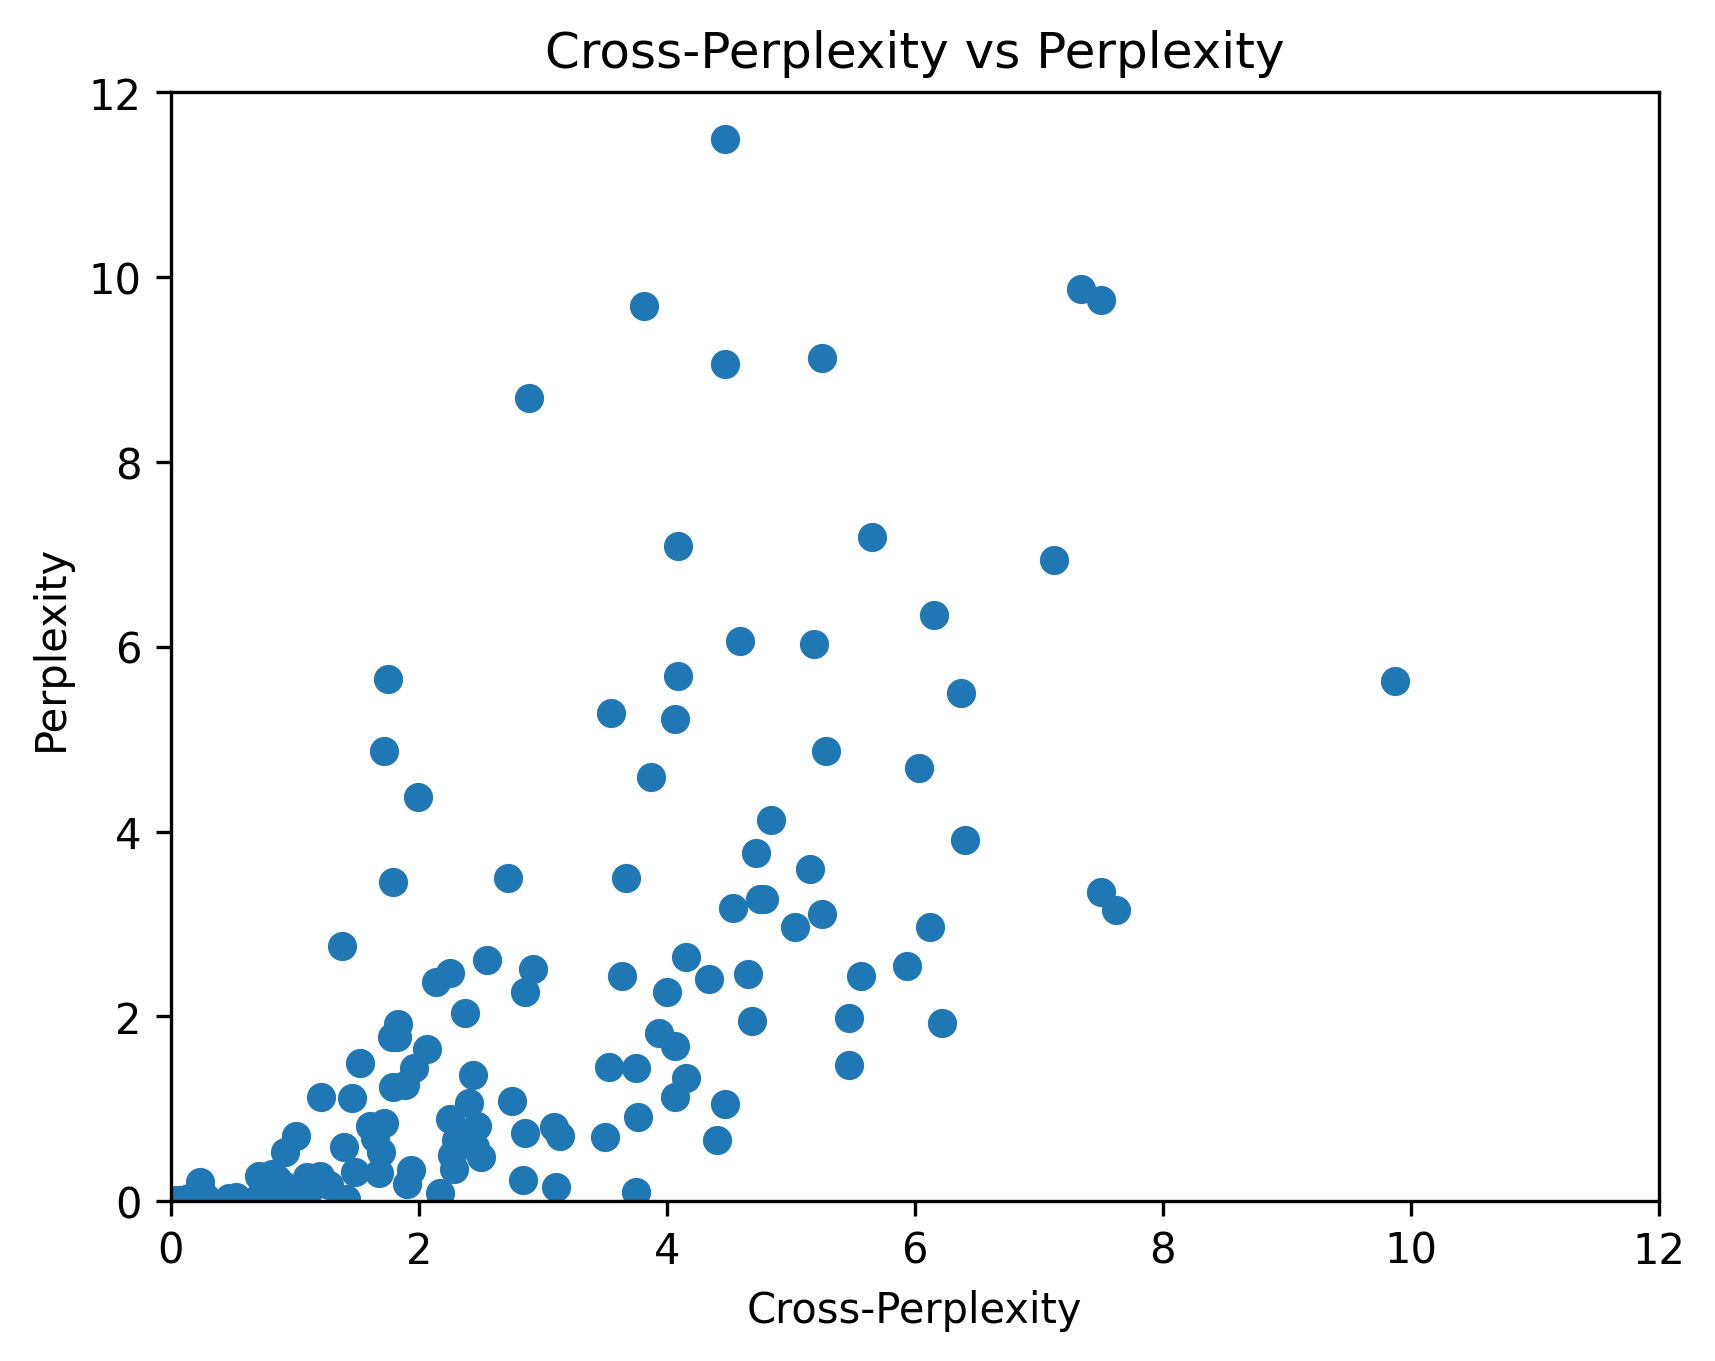

In [ ]:
plt.scatter(xppl.float(), ppl.float())
plt.title("Cross-Perplexity vs Perplexity")
plt.xlabel("Cross-Perplexity")
plt.ylabel("Perplexity")
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.show()


From the scatter plot, we see high density of tokens at the low perplexity and low cross-perplexity end, and more spread as perplexity increases.

In [ ]:
human = '''The healthcare industry typically draws sufficient attention to patients' education, especially when it comes to representatives of minority groups. That is why the article by McCurley et al. (2017) offers valuable information. The researchers demonstrate that Hispanic individuals deal with improved diabetes prevention when they participate in individual and group face-to-face sessions (McCurley et al., 2017). I believe that there is an apparent reason why such positive outcomes are achieved. It seems that face-to-face interventions are effective because patients have an opportunity to ask questions if they require explanations. Simultaneously, such educational sessions demonstrate that a patient is not unique with such a health issue. As a result, such interventions can improve people's morale, which, in turn, will lead to increased motivation to take preventive measures and protect health.'''

encoding = tokenize([human])

observer_logits, performer_logits = get_logits(encoding)

S = observer_logits.shape[-2]
V = observer_logits.shape[-1]


In [ ]:
shifted_logits = observer_logits[..., :-1, :].contiguous()
shifted_labels = encoding.input_ids[..., 1:].contiguous()

ppl = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels).float()

normalized_ppl = ppl / torch.max(ppl)

tokens = [tokenizer.decode([tok], clean_up_tokenization_spaces=False) for tok in encoding.input_ids.squeeze().tolist()]
html_output = generate_html(tokens, normalized_ppl)

display(HTML(html_output))

performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
observer_scores = observer_logits.view(-1, V).to("cpu")

xppl = loss_fn(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1).to("cpu").float()
normalized_xppl = xppl / torch.max(xppl)

html_output = generate_html(tokens, normalized_xppl)
display(HTML(html_output))

binocular_score = normalized_ppl / normalized_xppl
normalized_binocular_score = binocular_score / torch.max(binocular_score)

html_output = generate_html(tokens, normalized_binocular_score)
display(HTML(html_output))


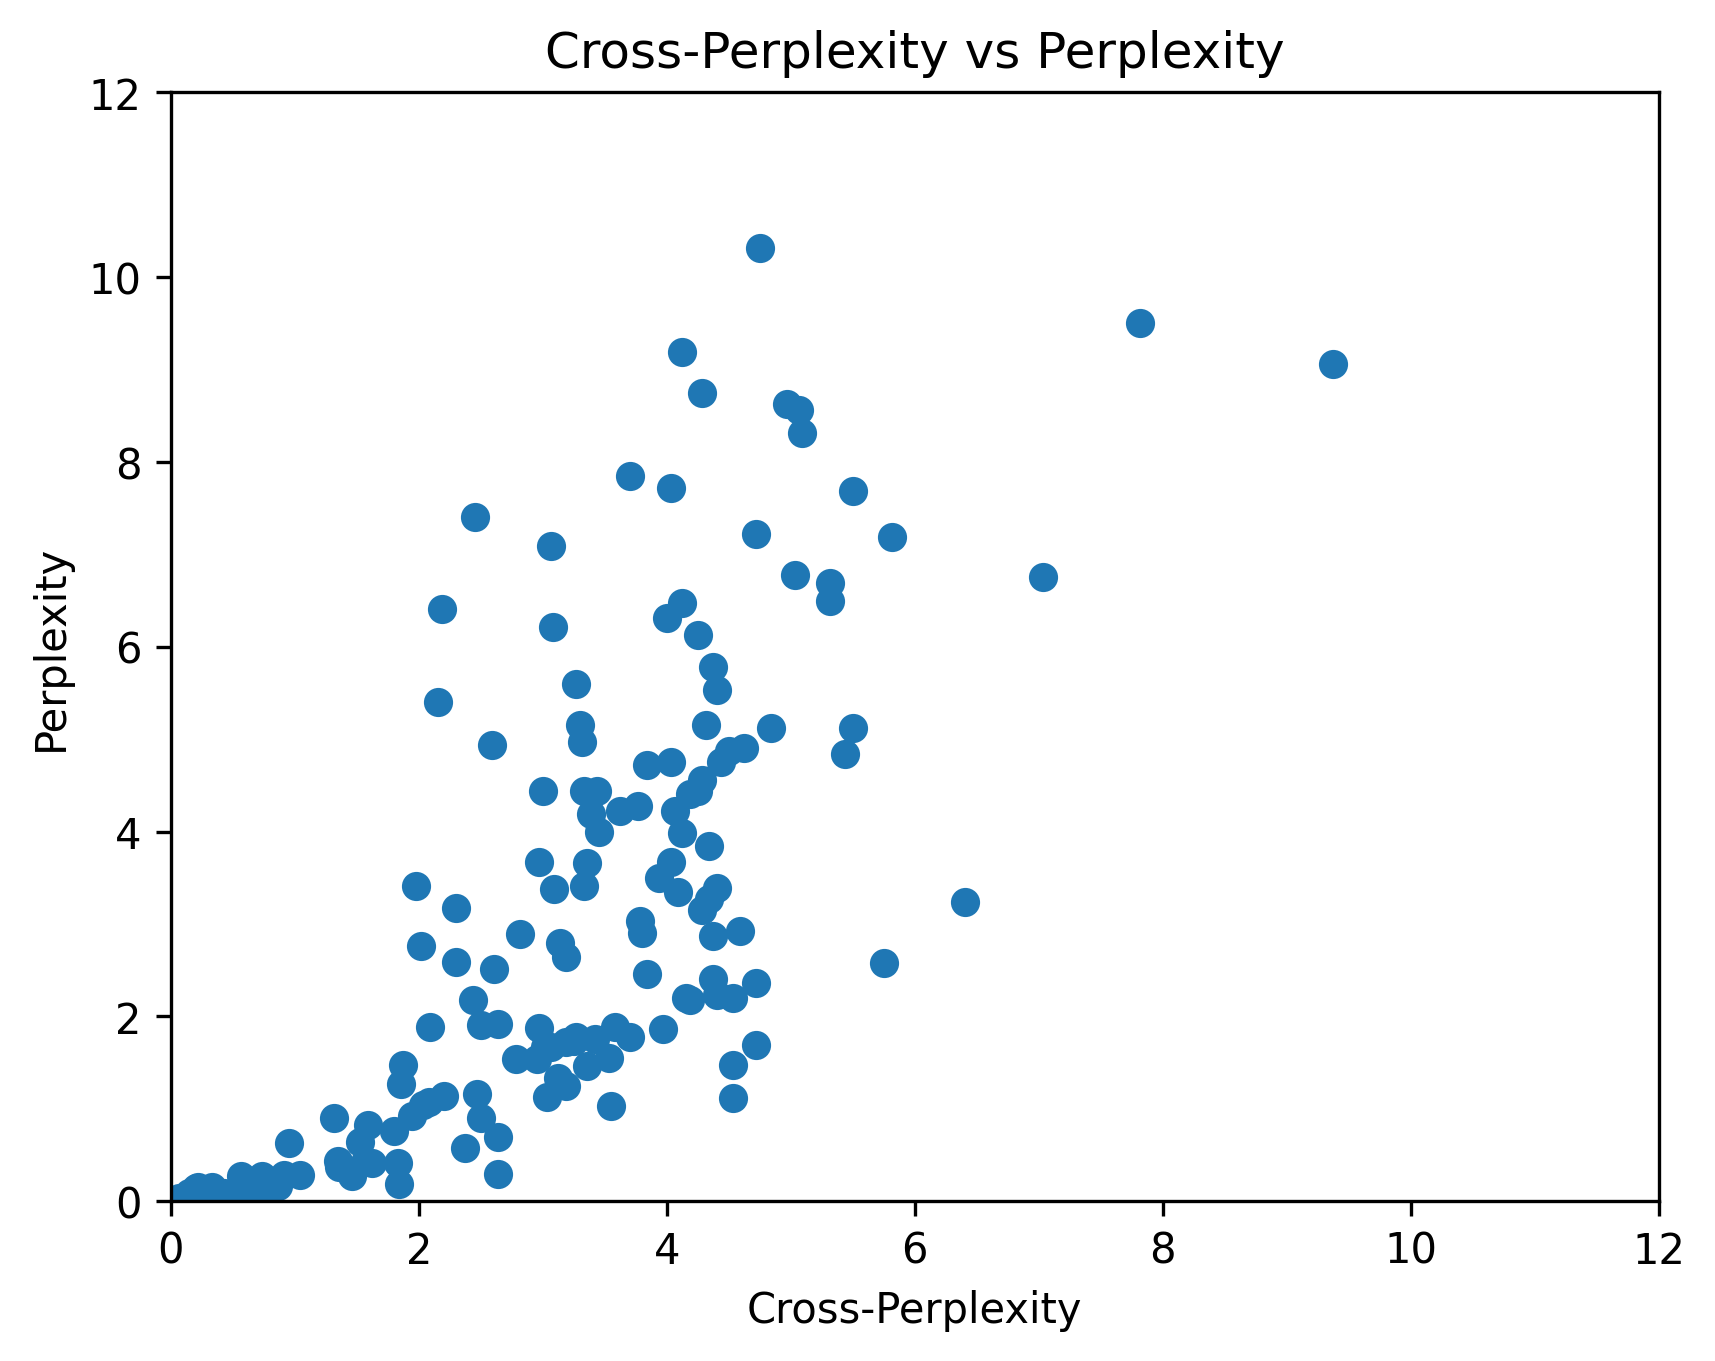

tensor([0.9932])

In [ ]:
plt.scatter(xppl.float(), ppl.float())
plt.title("Cross-Perplexity vs Perplexity")
plt.xlabel("Cross-Perplexity")
plt.ylabel("Perplexity")
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.show()

ppl.sum(1) / xppl.sum(1)


Compared to the previous perplexity scatter plot, there is much less spread and more values clustering around zero perplexity and cross-perplexity.

## Real application to a cover letter

In [ ]:
cover_letter_hybrid = ''' Dear Hiring Team,
I am writing to express my strong interest in the AI Scientist position at Mistral AI. Currently pursuing my Master’s degree at Télécom Paris and completing a Master 2 in Artificial Intelligence, Systems and Data (IASD) at Dauphine–PSL, I am seeking an end-of-study internship that aligns with my passion for cutting-edge AI research and offers the possibility to continue into a CIFRE PhD.
As part of a one-year academic gap, I had the opportunity to immerse myself in applied research projects bridging academia and industry. During this period, I worked as a Research Intern in Generative AI at MedirAI in Montreal, where I designed a sophisticated multimodal architecture leveraging state-of-the-art large language models, vision-language models, and image encoders to support melanoma diagnosis. This project involved fine-tuning models for the medical domain, researching interpretability techniques such as Grad-CAM, SHAP, and LIME, and building an API for seamless integration into clinical workflows. Additionally, I fine-tuned advanced segmentation models to improve lesion localization and developed automated interpretability reports via LLMs, enhancing clinician trust and system transparency.
Prior to this, as a Data Science and Data Engineering Intern, I contributed to a European digital health project focused on predicting patient fatigue levels using time series data from wearable sensors combined with clinical information. My role involved developing and applying machine learning and deep learning models for predictive analytics, as well as designing a Python package to standardize data loading and preprocessing across multiple partners, improving efficiency and reproducibility within the consortium.
My academic background at Télécom Paris, where I specialized in Image Processing and Signal Processing for Artificial Intelligence, combined with the rigorous training at Dauphine–PSL’s IASD program, has equipped me with both strong practical skills and a solid theoretical foundation. The IASD program further refines my understanding of machine learning and mathematics, which I consider essential preparation for pursuing a doctoral collaboration. This dual perspective prepares me to contribute effectively to innovative AI projects while also giving me the necessary keys to embark on a PhD.
I am particularly excited by Mistral AI’s mission to develop state-of-the-art models and push the frontier of generative AI technologies. My ambition is to begin by contributing as an intern and then continue this collaboration within a CIFRE PhD, combining impactful research with practical deployment of AI at scale.
I would welcome the opportunity to discuss how my background, skills, and research ambitions align with Mistral AI’s goals.
Thank you for considering my application. I look forward to the possibility of contributing to your team and advancing AI research together.
Sincerely,
Chloé Cour'''



encoding = tokenize([cover_letter_hybrid])

observer_logits, performer_logits = get_logits(encoding)

S = observer_logits.shape[-2]
V = observer_logits.shape[-1]

shifted_logits = observer_logits[..., :-1, :].contiguous()
shifted_labels = encoding.input_ids[..., 1:].contiguous()

ppl = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels).float()

normalized_ppl = ppl / torch.max(ppl)

tokens = [tokenizer.decode([tok], clean_up_tokenization_spaces=False) for tok in encoding.input_ids.squeeze().tolist()]
html_output = generate_html(tokens, normalized_ppl)

display(HTML(html_output))

performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
observer_scores = observer_logits.view(-1, V).to("cpu")

xppl = loss_fn(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1).to("cpu").float()
normalized_xppl = xppl / torch.max(xppl)

html_output = generate_html(tokens, normalized_xppl)
display(HTML(html_output))

binocular_score = normalized_ppl / normalized_xppl
normalized_binocular_score = binocular_score / torch.max(binocular_score)

html_output = generate_html(tokens, normalized_binocular_score)
display(HTML(html_output))


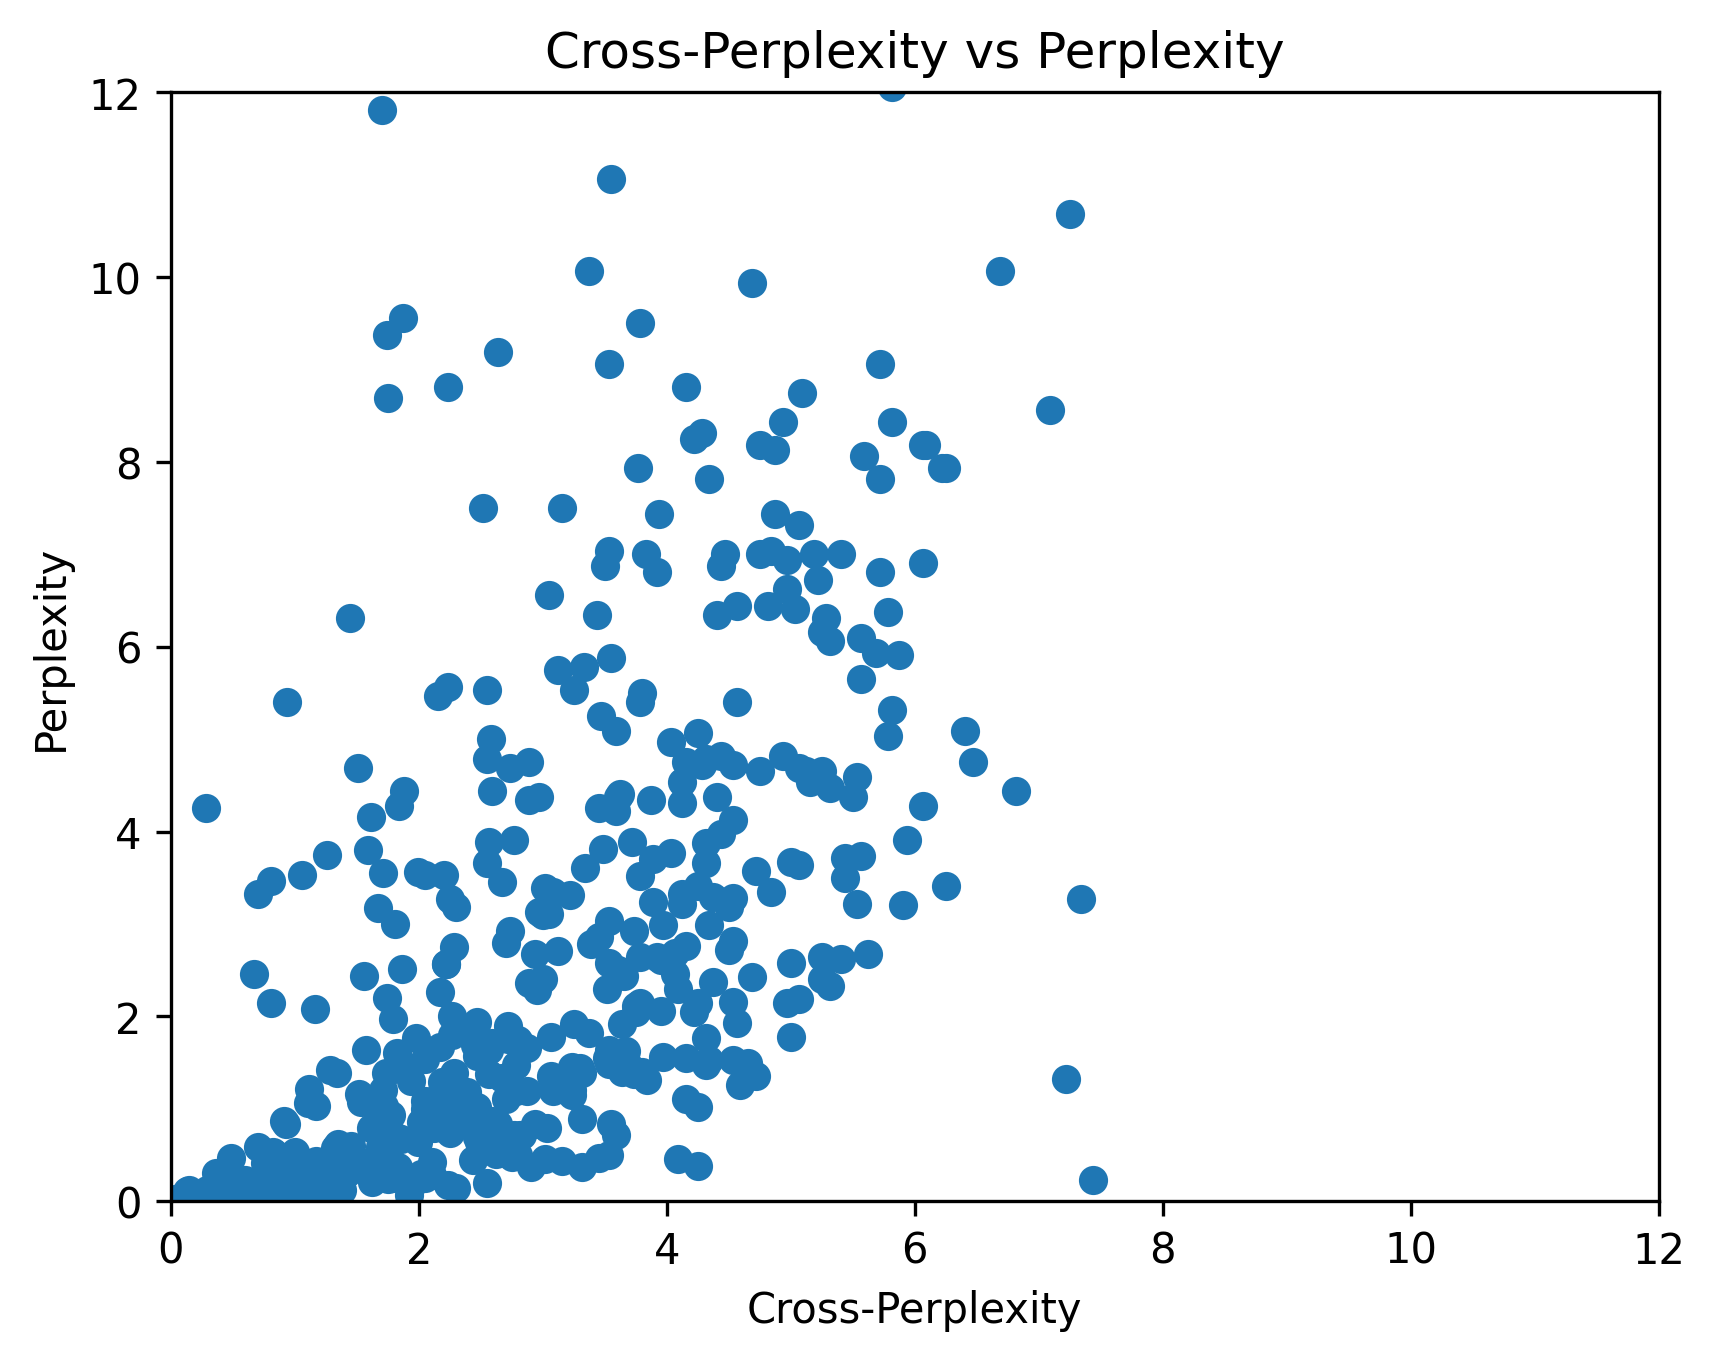

tensor([0.9536])

In [ ]:
plt.scatter(xppl.float(), ppl.float())
plt.title("Cross-Perplexity vs Perplexity")
plt.xlabel("Cross-Perplexity")
plt.ylabel("Perplexity")
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.show()

ppl.sum(1) / xppl.sum(1)


In [16]:
without_chat = ''' Ref: AI Data Platform Engineer Intern
Dear Doctolib SAS Talent Acquisition Team,
I am writing to express my interest in the AI Data Platform Engineer Intern Intern position at Doctolib. I am currently pursuing a Master 2 in Artificial Intelligence, System and Data at PSL, coordinated by ENS, Mines Paris, and Université Paris Dauphine, in parallel with my final year of engineering school at EURECOM. I am seeking a 6 month end-of-studies internship starting in April 2026 to apply my skills to impactful, real-world challenges in a data engineering position.
Applying AI models for healthcare deeply resonates with my values and it is the reason I chose my research project on the StressID dataset during my second year of engineering school. Under the supervision of Maria Zuluaga , during this project, I got to experiment with deep learning models to meet and exceed the baselines set with ML models on physiological data for stress prediction.
My experiences also extend to data science projects at an industry-level scale. For instance during my internship with Blunomy in Melbourne, where I got to lead a research study on state-wide long term time series forecasting as well as several pipeline-defining projects, each proving my strong programming skills, my effectiveness in collaborative working and my interest in applied research models to improve society, fully aligned with Doctolib’s mission.
Reading the topics I might work on during the internship only made me more confident in my desire for the position. Indeed, while all the 11 MLE topics would be perfect to apply my skillset that I am in the process of strengthening with my Master at PSL, my attention has been especially caught by the topics 4, 6 and 7, and the different fine tuning challenges they represent.
I am a hard worker, meet deadlines, and as an experienced programmer through my freelance work as well as internships, I have developed strong python programming skills, perseverance, and teamwork.
Thank you for taking the time to read my cover letter. If you have any questions, please do not hesitate to contact me. I can make myself available for an interview at any time.


I look forward to hearing from you. Yours faithfully,
Barthélémy Charlier

'''


encoding = tokenize([without_chat])

observer_logits, performer_logits = get_logits(encoding)

S = observer_logits.shape[-2]
V = observer_logits.shape[-1]

shifted_logits = observer_logits[..., :-1, :].contiguous()
shifted_labels = encoding.input_ids[..., 1:].contiguous()

ppl_2 = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels).float()

normalized_ppl = ppl_2 / torch.max(ppl_2)

tokens = [tokenizer.decode([tok], clean_up_tokenization_spaces=False) for tok in encoding.input_ids.squeeze().tolist()]
html_output = generate_html(tokens, normalized_ppl)

display(HTML(html_output))

performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
observer_scores = observer_logits.view(-1, V).to("cpu")

xppl_2 = loss_fn(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1).to("cpu").float()
normalized_xppl = xppl_2 / torch.max(xppl_2)

html_output = generate_html(tokens, normalized_xppl)
display(HTML(html_output))

binocular_score = normalized_ppl / normalized_xppl
normalized_binocular_score = binocular_score / torch.max(binocular_score)

html_output = generate_html(tokens, normalized_binocular_score)
display(HTML(html_output))




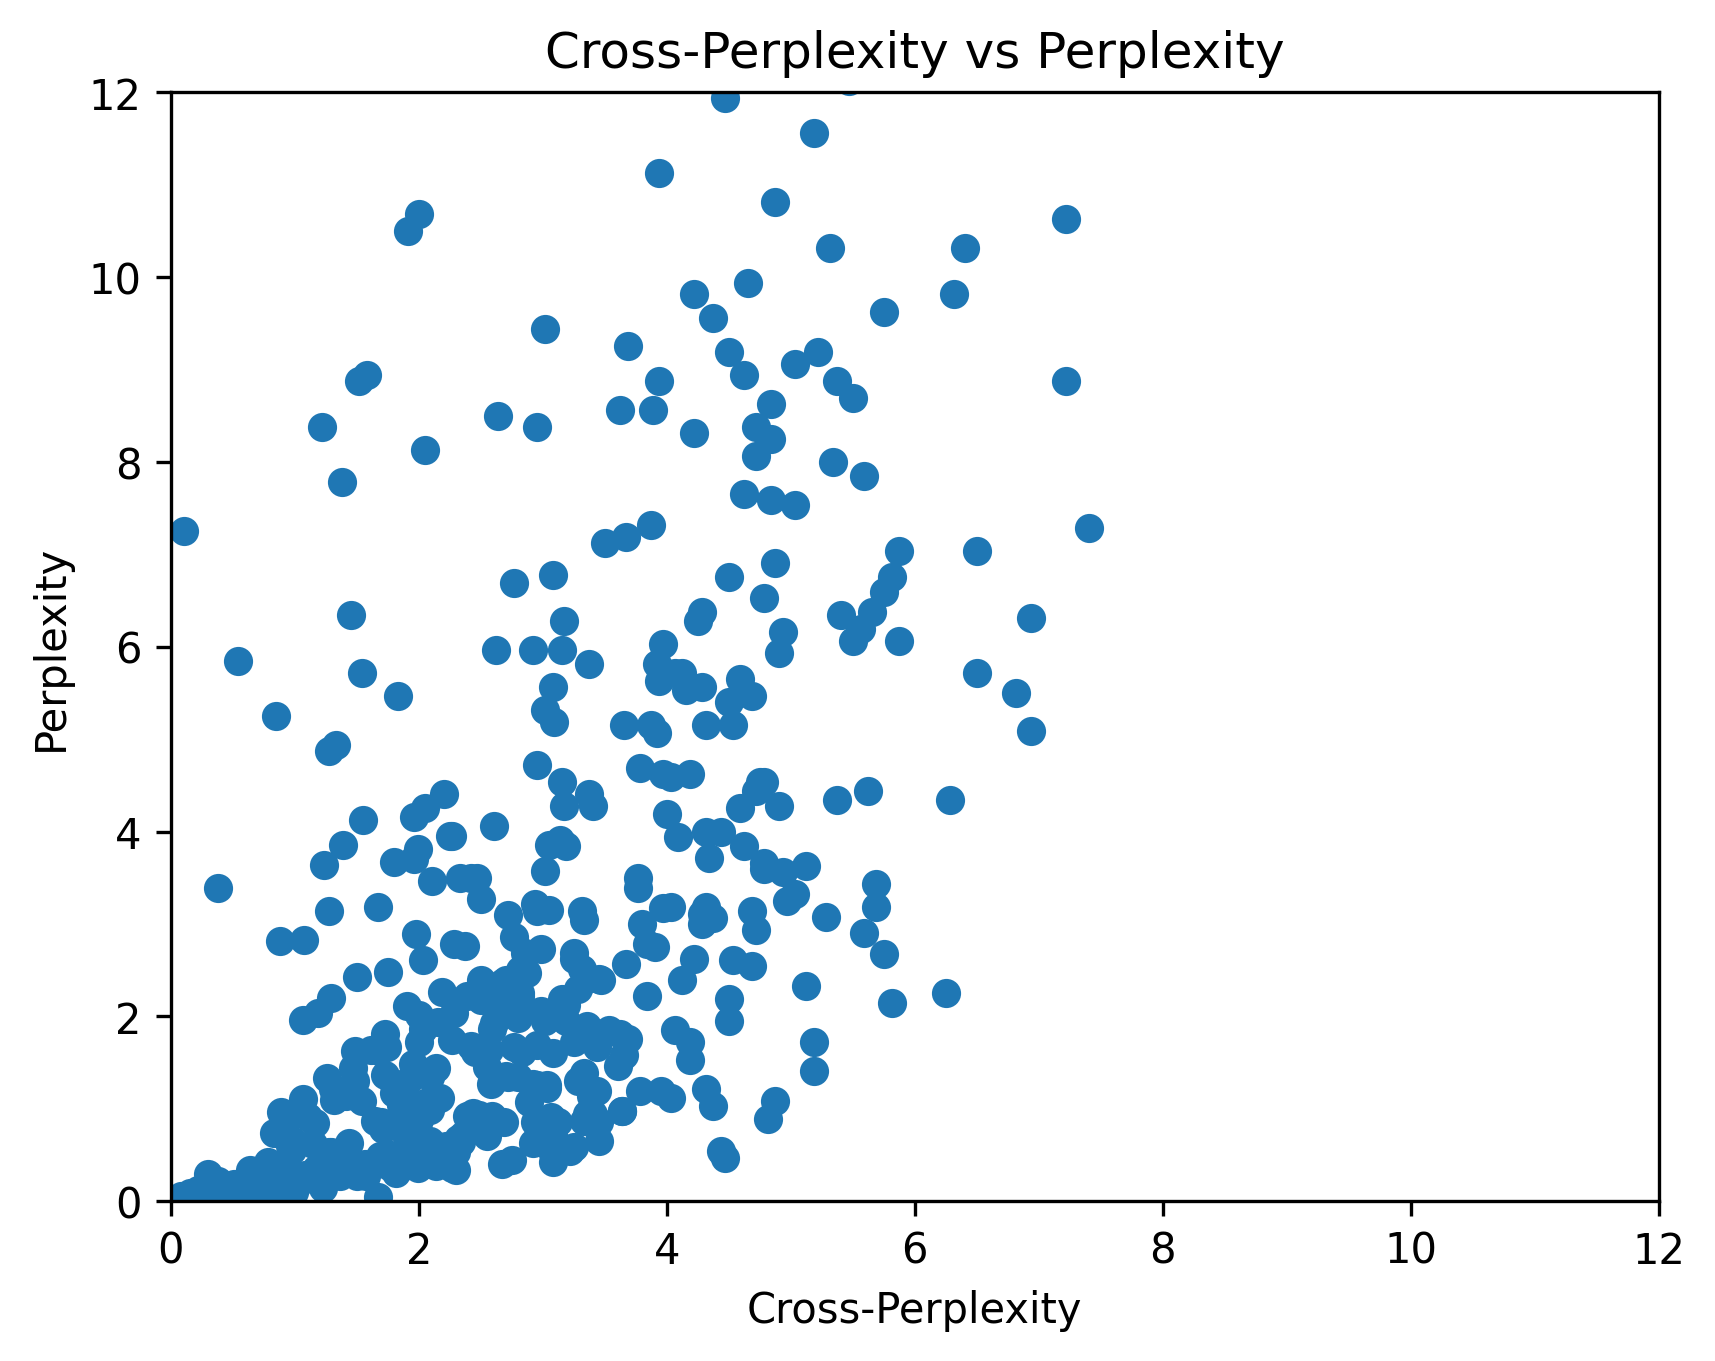

tensor([1.0480])

In [ ]:
plt.scatter(xppl_2.float(), ppl_2.float())
plt.title("Cross-Perplexity vs Perplexity")
plt.xlabel("Cross-Perplexity")
plt.ylabel("Perplexity")
plt.xlim(0, 12)
plt.ylim(0, 12)
plt.show()

ppl_2.sum(1) / xppl_2.sum(1)


In [ ]:
without_chat = ''' Ref: Machine Learning Research Intern

Dear Doctolib SAS Talent Acquisition Team,
I am writing to express my interest in the Machine Learning Research Intern position at Doctolib. I am currently pursuing a Master 2 in Artificial Intelligence at PSL, coordinated by ENS, Mines Paris, and Université Paris Dauphine, in parallel with my final year of engineering school at EURECOM. I am seeking a 6-month research internship starting in April 2026 to apply my skills in the domain of healthcare and the real-world challenges it faces.
Applying AI models in the field of healthcare deeply resonates with my professional aspirations and is the reason why I chose my research project on the StressID dataset during my second year at EURECOM. Under the supervision of Maria Zuluaga throughout this project, I was able to experiment with deep learning models to meet and exceed the baselines set using ML models on physiological data.
My acquired experience also extends to data science projects at an industry-level scale. During my internship at Blunomy in Melbourne, I had the opportunity to lead a research study on nation-wide long-term time series forecasting as well as several pipeline-defining projects, each demonstrating my strong programming skills, effectiveness in collaborative working and interest in applied research models for social development - an objective I believe is fully aligned with Doctolib’s mission.
Reading the topics I might work on during the internship only made me more confident in my desire for the position. While all eleven MLE topics would provide a great opportunity to apply my skillset that I am currently in the process of strengthening at PSL, my attention has been especially caught by the topics 4, 6, and 7, and the different fine-tuning challenges they represent.
The range of experiences I have so far acquired have taught me key soft skills in teamwork, perseverance and meeting tight deadlines. My work as an experienced programmer during both my freelance and internship positions have crucially allowed me to develop strong python programming skills.
Thank you in advance for your consideration. Please do not hesitate to get in touch should you have any questions. I am available for an interview at your earliest convenience.

Yours sincerely,
Barthélémy Charlier




'''


encoding = tokenize([without_chat])

observer_logits, performer_logits = get_logits(encoding)

S = observer_logits.shape[-2]
V = observer_logits.shape[-1]

shifted_logits = observer_logits[..., :-1, :].contiguous()
shifted_labels = encoding.input_ids[..., 1:].contiguous()

ppl_2 = loss_fn(shifted_logits.transpose(1, 2).to("cpu"), shifted_labels).float()

normalized_ppl = ppl_2 / torch.max(ppl_2)

tokens = [tokenizer.decode([tok], clean_up_tokenization_spaces=False) for tok in encoding.input_ids.squeeze().tolist()]
html_output = generate_html(tokens, normalized_ppl)

display(HTML(html_output))

performer_probs = softmax_fn(performer_logits).view(-1, V).to("cpu")
observer_scores = observer_logits.view(-1, V).to("cpu")

xppl_2 = loss_fn(observer_scores[:-1], performer_probs[:-1]).view(-1, S - 1).to("cpu").float()
normalized_xppl = xppl_2 / torch.max(xppl_2)

html_output = generate_html(tokens, normalized_xppl)
display(HTML(html_output))

binocular_score = normalized_ppl / normalized_xppl
normalized_binocular_score = binocular_score / torch.max(binocular_score)

html_output = generate_html(tokens, normalized_binocular_score)
display(HTML(html_output))


